### Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# For imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression, PoissonRegressor

# For EDA
import seaborn as sns
import matplotlib.pyplot as plt

### Load Datasets

In [2]:
INPUT_PATH_family = "cleaned data/family_good.csv"
INPUT_PATH_lab = "cleaned data/lab_final.csv"
INPUT_PATH_patient = "cleaned data/patient_good.csv"
INPUT_PATH_encounter = "cleaned data/encounter_dx_final.csv"

In [3]:
# Loding the encounter datasets
encounter = pd.read_csv(INPUT_PATH_encounter, sep = "|", low_memory=False) 
encounter.columns = encounter.columns.str.strip('"')
encounter.head(10)

,EncounterDiagnosis_ID,Network_ID,Site_ID,Patient_ID,Encounter_ID,Cycle_ID,DiagnosisText_orig,DiagnosisText_calc,DiagnosisCodeType_orig,DiagnosisCodeType_calc,DiagnosisCode_orig,DiagnosisCode_calc,DateCreated
0,1002000000000002,1,1000000000000004,1002000000032183,1.002000e+15,2015-Q2,Diabetes Mellitus -Type 1- Insulin Dependent,TYPE I DIABETES MELLITUS [INSULIN DEPENDENT TY...,ICD9,ICD9,250.01,250.01,2008-08-05 00:00:00
1,1002000000000003,1,1000000000000004,1002000000032183,1.002000e+15,2015-Q2,Hep A and Hep B Combined Vaccine,NaN,NaN,NaN,NaN,NaN,2008-08-05 00:00:00
2,1002000000000004,1,1000000000000004,1002000000032183,1.002000e+15,2015-Q2,Pre Natal Form,NaN,NaN,NaN,NaN,NaN,2008-08-05 00:00:00
3,1002000000000005,1,1000000000000004,1002000000013966,1.002000e+15,2015-Q2,general symptoms genx,GENERAL SYMPTOMS,ICD9,ICD9,780,780,2008-09-04 00:00:00
4,1002000000000006,1,1000000000000004,1002000000024045,1.002000e+15,2015-Q2,Obesity,OVERWEIGHT AND OBESITY,ICD9,ICD9,278.0,278.0,2008-09-11 00:00:00
5,1002000000000007,1,1000000000000004,1002000000006790,1.002000e+15,2015-Q2,examination (general) (routine),ROUTINE GENERAL MEDICAL EXAMINATION AT A HEALT...,ICD9,ICD9,V70.0,V70.0,2008-09-12 00:00:00
6,1002000000000008,1,1000000000000004,1002000000005174,1.002000e+15,2015-Q2,Esophageal Cancer,MALIGNANT NEOPLASM OF ESOPHAGUS,ICD9,ICD9,150,150,2008-09-05 00:00:00
7,1002000000000009,1,1000000000000004,1002000000032183,1.002000e+15,2015-Q2,Headache,HEADACHE,ICD9,ICD9,784.0,784.0,2008-08-07 00:00:00
8,1002000000000010,1,1000000000000004,1002000000015606,1.002000e+15,2015-Q2,examination (general) (routine),ROUTINE GENERAL MEDICAL EXAMINATION AT A HEALT...,ICD9,ICD9,V70.0,V70.0,2008-09-11 00:00:00
9,1002000000000011,1,1000000000000004,1002000000014862,1.002000e+15,2015-Q2,Abnormal paps,NaN,NaN,NaN,NaN,NaN,2008-09-05 00:00:00


In [4]:
# Check data type
encounter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12471785 entries, 0 to 12471784
Data columns (total 13 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   EncounterDiagnosis_ID   int64  
 1   Network_ID              int64  
 2   Site_ID                 int64  
 3   Patient_ID              int64  
 4   Encounter_ID            float64
 5   Cycle_ID                object 
 6   DiagnosisText_orig      object 
 7   DiagnosisText_calc      object 
 8   DiagnosisCodeType_orig  object 
 9   DiagnosisCodeType_calc  object 
 10  DiagnosisCode_orig      object 
 11  DiagnosisCode_calc      object 
 12  DateCreated             object 
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ GB


In [5]:
### change columns in encounter table, DateCreated 
encounter['DateCreated'] = pd.to_datetime(encounter['DateCreated'], format = 'mixed', errors = 'coerce')

In [6]:
# cleaned encounter, based on Data Dictionary, the _calc columns are the _orig column into consistent text, so we only
# incude the _calc columns in the cleaned encounter table 
encounter_clean = encounter[['EncounterDiagnosis_ID', 'Patient_ID', 'Encounter_ID', 'DiagnosisText_calc', 
                             'DiagnosisCodeType_calc', 'DiagnosisCode_calc', 'DateCreated']]
encounter_clean.head(10)

,EncounterDiagnosis_ID,Patient_ID,Encounter_ID,DiagnosisText_calc,DiagnosisCodeType_calc,DiagnosisCode_calc,DateCreated
0,1002000000000002,1002000000032183,1.002000e+15,TYPE I DIABETES MELLITUS [INSULIN DEPENDENT TY...,ICD9,250.01,2008-08-05
1,1002000000000003,1002000000032183,1.002000e+15,NaN,NaN,NaN,2008-08-05
2,1002000000000004,1002000000032183,1.002000e+15,NaN,NaN,NaN,2008-08-05
3,1002000000000005,1002000000013966,1.002000e+15,GENERAL SYMPTOMS,ICD9,780,2008-09-04
4,1002000000000006,1002000000024045,1.002000e+15,OVERWEIGHT AND OBESITY,ICD9,278.0,2008-09-11
5,1002000000000007,1002000000006790,1.002000e+15,ROUTINE GENERAL MEDICAL EXAMINATION AT A HEALT...,ICD9,V70.0,2008-09-12
6,1002000000000008,1002000000005174,1.002000e+15,MALIGNANT NEOPLASM OF ESOPHAGUS,ICD9,150,2008-09-05
7,1002000000000009,1002000000032183,1.002000e+15,HEADACHE,ICD9,784.0,2008-08-07
8,1002000000000010,1002000000015606,1.002000e+15,ROUTINE GENERAL MEDICAL EXAMINATION AT A HEALT...,ICD9,V70.0,2008-09-11
9,1002000000000011,1002000000014862,1.002000e+15,NaN,NaN,NaN,2008-09-05


In [7]:
encounter_clean['DiagnosisCodeType_calc'].unique() # checked: only ICD9 code type included 
encounter_clean['Patient_ID'].nunique() # total number of patients (unfiltered): 352161

352161

In [8]:
# Loding the lab datasets
lab = pd.read_csv(INPUT_PATH_lab, sep = "|", low_memory=False) 
lab.columns = lab.columns.str.strip('"')
lab.head(10)

,Lab_ID,Network_ID,Site_ID,Patient_ID,Encounter_ID,Cycle_ID,PerformedDate,Name_orig,Name_calc,CodeType_orig,...,Code_orig,Code_calc,TestResult_orig,TestResult_calc,UpperNormal,LowerNormal,NormalRange,UnitOfMeasure_orig,UnitOfMeasure_calc,DateCreated
0,1002000000000001,1,1000000000000004,1002000000228146,NaN,2015-Q2,2008-08-11 00:00:00,INR,INR,NaN,...,NaN,6301-6,1.8,1.8,1.1,0.9,0.9-1.1,NaN,NaN,2008-08-11 00:00:00
1,1002000000000002,1,1000000000000004,1002000000031629,NaN,2015-Q2,2008-08-11 00:00:00,INR,INR,NaN,...,NaN,6301-6,4.7,4.7,1.1,0.9,0.9-1.1,NaN,NaN,2008-08-11 00:00:00
2,1002000000000003,1,1000000000000004,1002000000227103,NaN,2015-Q2,2008-08-11 00:00:00,INR,INR,NaN,...,NaN,6301-6,2.1,2.1,1.1,0.9,0.9-1.1,NaN,NaN,2008-08-11 00:00:00
3,1002000000000004,1,1000000000000004,1002000000227385,NaN,2015-Q2,2007-08-23 00:00:00,GLUCOSE FASTING,FASTING GLUCOSE,NaN,...,NaN,14771-0,5.6,5.6,6.1,3.9,3.9-6.1,mmol/L,mmol/L,2007-08-23 00:00:00
4,1002000000000005,1,1000000000000004,1002000000036134,NaN,2015-Q2,2007-08-23 00:00:00,INR,INR,NaN,...,NaN,6301-6,3.1,3.1,1.1,0.9,0.9-1.1,NaN,NaN,2007-08-23 00:00:00
5,1002000000000011,1,1000000000000004,1002000000007912,NaN,2015-Q2,2007-08-23 00:00:00,LDL Calculated,LDL,NaN,...,NaN,22748-8,2.49,2.49,3.0,1.7,1.70-3.00,mmol/L,mmol/L,2007-08-23 00:00:00
6,1002000000000012,1,1000000000000004,1002000000042535,NaN,2015-Q2,2007-08-23 00:00:00,GLUCOSE FASTING,FASTING GLUCOSE,NaN,...,NaN,14771-0,5.5,5.5,6.1,3.9,3.9-6.1,mmol/L,mmol/L,2007-08-23 00:00:00
7,1002000000000013,1,1000000000000004,1002000000017980,NaN,2015-Q2,2007-08-22 00:00:00,HbA1c,HBA1C,NaN,...,NaN,17856-6,6.1,6.1,6.1,4.3,4.3-6.1,%,%,2007-08-22 00:00:00
8,1002000000000014,1,1000000000000004,1002000000007912,NaN,2015-Q2,2007-08-23 00:00:00,CHOLESTEROL,TOTAL CHOLESTEROL,NaN,...,NaN,14647-2,4.43,4.43,4.6,3.2,3.20-4.60,mmol/L,mmol/L,2007-08-23 00:00:00
9,1002000000000015,1,1000000000000004,1002000000007912,NaN,2015-Q2,2007-08-23 00:00:00,TRIGLYCERIDES,TRIGLYCERIDES,NaN,...,NaN,14927-8,2.15,2.15,2.3,0.6,0.60-2.30,mmol/L,mmol/L,2007-08-23 00:00:00


In [9]:
# Check data type
lab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8528789 entries, 0 to 8528788
Data columns (total 21 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Lab_ID              int64  
 1   Network_ID          int64  
 2   Site_ID             int64  
 3   Patient_ID          int64  
 4   Encounter_ID        float64
 5   Cycle_ID            object 
 6   PerformedDate       object 
 7   Name_orig           object 
 8   Name_calc           object 
 9   CodeType_orig       object 
 10  CodeType_calc       object 
 11  Code_orig           object 
 12  Code_calc           object 
 13  TestResult_orig     object 
 14  TestResult_calc     object 
 15  UpperNormal         object 
 16  LowerNormal         object 
 17  NormalRange         object 
 18  UnitOfMeasure_orig  object 
 19  UnitOfMeasure_calc  object 
 20  DateCreated         object 
dtypes: float64(1), int64(4), object(16)
memory usage: 1.3+ GB


In [10]:
### change columns in lab table, PerformedDate, DateCreated 
lab['PerformedDate'] = pd.to_datetime(lab['PerformedDate'], format = 'mixed', errors = 'coerce')
lab['DateCreated'] = pd.to_datetime(lab['DateCreated'], format = 'mixed', errors = 'coerce')

In [11]:
# cleaned lab, based on Data Dictionary, the _calc columns are the _orig column into consistent text, so we only
# incude the _calc columns in the cleaned lab table 
lab_clean = lab[['Patient_ID', 'PerformedDate', 'Name_calc', 'CodeType_calc', 'Code_calc', 'TestResult_calc', 
                             'UpperNormal', 'LowerNormal', 'NormalRange', 'DateCreated']]
lab_clean.head(10)

,Patient_ID,PerformedDate,Name_calc,CodeType_calc,Code_calc,TestResult_calc,UpperNormal,LowerNormal,NormalRange,DateCreated
0,1002000000228146,2008-08-11,INR,LOINC,6301-6,1.8,1.1,0.9,0.9-1.1,2008-08-11
1,1002000000031629,2008-08-11,INR,LOINC,6301-6,4.7,1.1,0.9,0.9-1.1,2008-08-11
2,1002000000227103,2008-08-11,INR,LOINC,6301-6,2.1,1.1,0.9,0.9-1.1,2008-08-11
3,1002000000227385,2007-08-23,FASTING GLUCOSE,LOINC,14771-0,5.6,6.1,3.9,3.9-6.1,2007-08-23
4,1002000000036134,2007-08-23,INR,LOINC,6301-6,3.1,1.1,0.9,0.9-1.1,2007-08-23
5,1002000000007912,2007-08-23,LDL,LOINC,22748-8,2.49,3.0,1.7,1.70-3.00,2007-08-23
6,1002000000042535,2007-08-23,FASTING GLUCOSE,LOINC,14771-0,5.5,6.1,3.9,3.9-6.1,2007-08-23
7,1002000000017980,2007-08-22,HBA1C,LOINC,17856-6,6.1,6.1,4.3,4.3-6.1,2007-08-22
8,1002000000007912,2007-08-23,TOTAL CHOLESTEROL,LOINC,14647-2,4.43,4.6,3.2,3.20-4.60,2007-08-23
9,1002000000007912,2007-08-23,TRIGLYCERIDES,LOINC,14927-8,2.15,2.3,0.6,0.60-2.30,2007-08-23


In [12]:
lab_clean['Name_calc'].unique() # checked: only BMI, HbA1c, and Glucose included 
lab_clean['Patient_ID'].nunique() # total number of patients (unfiltered): 207836

207836

In [13]:
# Loding the patient datasets
patient = pd.read_csv(INPUT_PATH_patient, sep = "|", low_memory=False) 
patient.columns = patient.columns.str.strip('"')
patient.head(10)

,Patient_ID,Sex,BirthYear,BirthMonth,OptedOut,OptOutDate
0,1002000000000009,Female,2010.0,NaN,False,NaN
1,1002000000000010,Female,2007.0,NaN,False,NaN
2,1002000000000015,Male,1972.0,NaN,False,NaN
3,1002000000000016,Male,1965.0,NaN,False,NaN
4,1002000000000020,Male,1999.0,NaN,False,NaN
5,1002000000000024,Female,1955.0,NaN,False,NaN
6,1002000000000039,Male,1999.0,NaN,False,NaN
7,1002000000000044,Female,1949.0,NaN,False,NaN
8,1002000000000046,Male,2010.0,NaN,False,NaN
9,1002000000000049,Male,1965.0,NaN,False,NaN


In [14]:
# Check data type
patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352161 entries, 0 to 352160
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Patient_ID  352161 non-null  int64  
 1   Sex         352121 non-null  object 
 2   BirthYear   352020 non-null  float64
 3   BirthMonth  211940 non-null  float64
 4   OptedOut    352161 non-null  bool   
 5   OptOutDate  0 non-null       float64
dtypes: bool(1), float64(3), int64(1), object(1)
memory usage: 13.8+ MB


In [15]:
# cleaned patient, based on Data Dictionary, incude the patient_id, sex, birthyear columns in the cleaned patient table  
patient_clean = patient[['Patient_ID', 'Sex', 'BirthYear']]
patient_clean.head(10)

,Patient_ID,Sex,BirthYear
0,1002000000000009,Female,2010.0
1,1002000000000010,Female,2007.0
2,1002000000000015,Male,1972.0
3,1002000000000016,Male,1965.0
4,1002000000000020,Male,1999.0
5,1002000000000024,Female,1955.0
6,1002000000000039,Male,1999.0
7,1002000000000044,Female,1949.0
8,1002000000000046,Male,2010.0
9,1002000000000049,Male,1965.0


In [16]:
patient_clean['Patient_ID'].nunique() # total number of patients (unfiltered): 352161

352161

In [17]:
# Loding the family history datasets
family = pd.read_csv(INPUT_PATH_family, sep = "|", low_memory=False) 
family.columns = family.columns.str.strip('"')
family.head(10)

,FamilyHistory_ID,Network_ID,Site_ID,Patient_ID,Encounter_ID,Cycle_ID,DiagnosisText_orig,DiagnosisText_calc,DiagnosisCodeType_orig,DiagnosisCodeType_calc,DiagnosisCode_orig,DiagnosisCode_calc,Relationship_orig,Relationship_Side_calc,Relationship_Degree_calc,AgeAtOnset,VitalStatus,WasCauseOfDeath,AgeAtDeath,DateCreated
0,4001000000000001,4,4000000000000001,4001000000000001,NaN,2015-Q2,"DISORDERS OF LIPOID METABOLISM, E.G. HYPERCHOL...",NaN,ICD(ONT),NaN,272,NaN,father,NaN,NaN,NaN,Unknown,False,NaN,2011-02-22 00:00:00
1,4001000000000002,4,4000000000000001,4001000000000001,NaN,2015-Q2,"DISORDERS OF LIPOID METABOLISM, E.G. HYPERCHOL...",NaN,ICD(ONT),NaN,272,NaN,mother,NaN,NaN,NaN,Unknown,False,NaN,2011-02-22 00:00:00
2,4001000000000003,4,4000000000000001,4001000000000018,NaN,2015-Q2,MALIGNANT NEOPLASMS - PROSTATE,NaN,ICD(ONT),NaN,185,NaN,paternal grandfather,NaN,NaN,NaN,Unknown,False,NaN,2013-11-26 00:00:00
3,4001000000000004,4,4000000000000001,4001000000000029,NaN,2015-Q2,MALIGNANT NEOPLASMS - CERVIX Born in 1955 CIN I,NaN,ICD(ONT),NaN,180,NaN,sister,NaN,NaN,NaN,Unknown,False,NaN,2011-11-07 00:00:00
4,4001000000000005,4,4000000000000001,4001000000000029,NaN,2015-Q2,SIMPLE THYROID GOITER thyroid problems born i...,NaN,ICD(ONT),NaN,240,NaN,sister,NaN,NaN,NaN,Unknown,False,NaN,2009-03-22 00:00:00
5,4001000000000008,4,4000000000000001,4001000000000134,NaN,2015-Q2,ALL OTHER FORMS OF HEART DISEASE died at age 91,NaN,ICD(ONT),NaN,429,NaN,mother,NaN,NaN,NaN,Deceased,True,NaN,2009-10-21 00:00:00
6,4001000000000009,4,4000000000000001,4001000000000134,NaN,2015-Q2,"MALIGNANT NEOPLASMS - METASTATIC OR SECONDARY,...",NaN,ICD(ONT),NaN,198,NaN,father,NaN,NaN,NaN,Deceased,True,NaN,2009-10-21 00:00:00
7,4001000000000010,4,4000000000000001,4001000000000162,NaN,2015-Q2,ACUTE MYOCARDIAL INFRACTION 60,NaN,ICD(ONT),NaN,410,NaN,maternal grandfather,NaN,NaN,NaN,Unknown,False,NaN,2006-06-27 00:00:00
8,4001000000000011,4,4000000000000001,4001000000000177,NaN,2015-Q2,ACUTE MYOCARDIAL INFRACTION 70s,NaN,ICD(ONT),NaN,410,NaN,paternal grandfather,NaN,NaN,NaN,Unknown,False,NaN,2006-06-29 00:00:00
9,4001000000000012,4,4000000000000001,4001000000000192,NaN,2015-Q2,[Phone],NaN,ICD(ONT),NaN,799,NaN,father,NaN,NaN,NaN,Unknown,False,NaN,2009-07-13 00:00:00


In [18]:
# Check data type
family.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325202 entries, 0 to 325201
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   FamilyHistory_ID          325202 non-null  int64  
 1   Network_ID                325202 non-null  int64  
 2   Site_ID                   325202 non-null  int64  
 3   Patient_ID                325202 non-null  int64  
 4   Encounter_ID              12130 non-null   float64
 5   Cycle_ID                  325202 non-null  object 
 6   DiagnosisText_orig        298359 non-null  object 
 7   DiagnosisText_calc        0 non-null       float64
 8   DiagnosisCodeType_orig    154076 non-null  object 
 9   DiagnosisCodeType_calc    0 non-null       float64
 10  DiagnosisCode_orig        153947 non-null  object 
 11  DiagnosisCode_calc        0 non-null       float64
 12  Relationship_orig         297779 non-null  object 
 13  Relationship_Side_calc    0 non-null       f

In [19]:
### change columns in family table, DateCreated 
family['DateCreated'] = pd.to_datetime(family['DateCreated'], format = 'mixed', errors = 'coerce')

In [20]:
# cleaned family, based on Data Dictionary, only incude the _orig columns in the cleaned family table
family_clean = family[['Patient_ID', 'DiagnosisText_orig', 'DiagnosisCodeType_orig', 'DiagnosisCode_orig',
                      'Relationship_orig', 'VitalStatus', 'WasCauseOfDeath', 'DateCreated']]
family_clean.head(10)

,Patient_ID,DiagnosisText_orig,DiagnosisCodeType_orig,DiagnosisCode_orig,Relationship_orig,VitalStatus,WasCauseOfDeath,DateCreated
0,4001000000000001,"DISORDERS OF LIPOID METABOLISM, E.G. HYPERCHOL...",ICD(ONT),272,father,Unknown,False,2011-02-22
1,4001000000000001,"DISORDERS OF LIPOID METABOLISM, E.G. HYPERCHOL...",ICD(ONT),272,mother,Unknown,False,2011-02-22
2,4001000000000018,MALIGNANT NEOPLASMS - PROSTATE,ICD(ONT),185,paternal grandfather,Unknown,False,2013-11-26
3,4001000000000029,MALIGNANT NEOPLASMS - CERVIX Born in 1955 CIN I,ICD(ONT),180,sister,Unknown,False,2011-11-07
4,4001000000000029,SIMPLE THYROID GOITER thyroid problems born i...,ICD(ONT),240,sister,Unknown,False,2009-03-22
5,4001000000000134,ALL OTHER FORMS OF HEART DISEASE died at age 91,ICD(ONT),429,mother,Deceased,True,2009-10-21
6,4001000000000134,"MALIGNANT NEOPLASMS - METASTATIC OR SECONDARY,...",ICD(ONT),198,father,Deceased,True,2009-10-21
7,4001000000000162,ACUTE MYOCARDIAL INFRACTION 60,ICD(ONT),410,maternal grandfather,Unknown,False,2006-06-27
8,4001000000000177,ACUTE MYOCARDIAL INFRACTION 70s,ICD(ONT),410,paternal grandfather,Unknown,False,2006-06-29
9,4001000000000192,[Phone],ICD(ONT),799,father,Unknown,False,2009-07-13


In [21]:
family_clean['Patient_ID'].nunique() # total number of patients (unfiltered): 92902

92902

### Detect Missingness and EDA: Visualizing Missingness

#### Encounter

In [22]:
# Detect Missingness in enounter dataset
encounter_missing_counts = encounter_clean.isna().sum()

# To see the percentage of missing data per column instead of raw counts:
encounter_missing_percentage = (encounter_clean.isna().sum() / len(encounter_clean)) * 100

# Combine into a summary table
encounter_missing_summary = pd.concat([encounter_missing_counts, encounter_missing_percentage], axis=1)
encounter_missing_summary.columns = ['Missing Count', 'Percentage']

encounter_missing_summary.sort_values(by = 'Percentage', ascending=False)

,Missing Count,Percentage
DiagnosisText_calc,4334813,34.756957
DiagnosisCodeType_calc,4334813,34.756957
DiagnosisCode_calc,4334813,34.756957
Encounter_ID,171801,1.377517
EncounterDiagnosis_ID,0,0.000000
Patient_ID,0,0.000000
DateCreated,0,0.000000


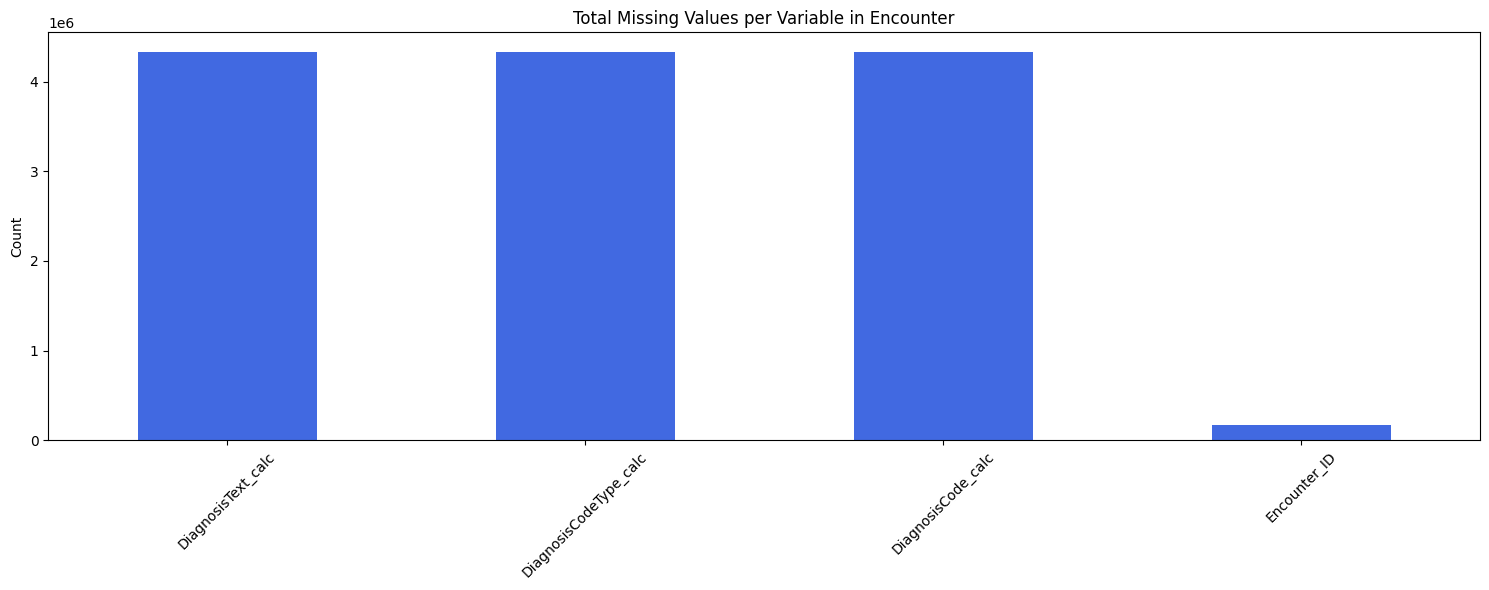

In [23]:
ax1 = encounter_missing_counts[encounter_missing_counts > 0].sort_values(ascending=False).plot(
    kind='bar', 
    color='royalblue',
    figsize=(15, 6)
)

ax1.tick_params(axis='x', rotation=45) 
ax1.set_title('Total Missing Values per Variable in Encounter')
ax1.set_ylabel('Count')

plt.tight_layout() 
plt.show()

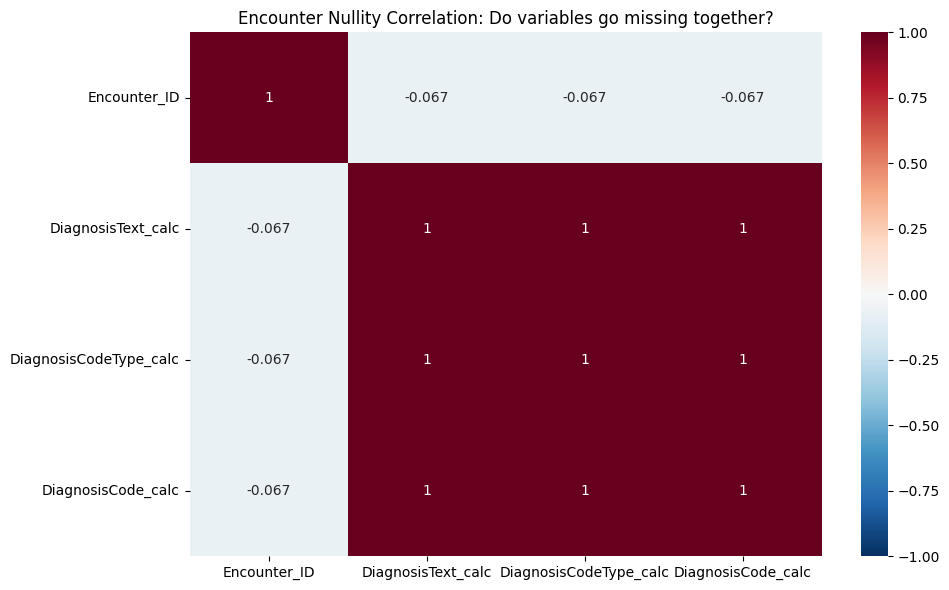

In [24]:
# Identify columns with missing values
encounter_missing_cols = encounter_clean.columns[encounter_clean.isnull().any()].tolist()
 
# Create binary indicators (1 = Missing, 0 = Present)
encounter_indicators = encounter_clean[encounter_missing_cols].isnull().astype(int)
 
# Calculate Nullity Correlation
encounter_nullity_corr = encounter_indicators.corr()
 
# Plot the results
plt.figure(figsize=(10, 6))
sns.heatmap(encounter_nullity_corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Encounter Nullity Correlation: Do variables go missing together?')
plt.tight_layout()

#### Lab

In [25]:
# Detect Missingness in lab dataset
lab_missing_counts = lab_clean.isna().sum()

# To see the percentage of missing data per column instead of raw counts:
lab_missing_percentage = (lab_clean.isna().sum() / len(lab_clean)) * 100

# Combine into a summary table
lab_missing_summary = pd.concat([lab_missing_counts, lab_missing_percentage], axis=1)
lab_missing_summary.columns = ['Missing Count', 'Percentage']

lab_missing_summary.sort_values(by = 'Percentage', ascending=False)

,Missing Count,Percentage
LowerNormal,7249866,85.004635
UpperNormal,7169456,84.061829
TestResult_calc,4176961,48.974843
Name_calc,4028588,47.235170
CodeType_calc,4028588,47.235170
Code_calc,4028588,47.235170
NormalRange,3494872,40.977353
PerformedDate,1916,0.022465
Patient_ID,0,0.000000
DateCreated,0,0.000000


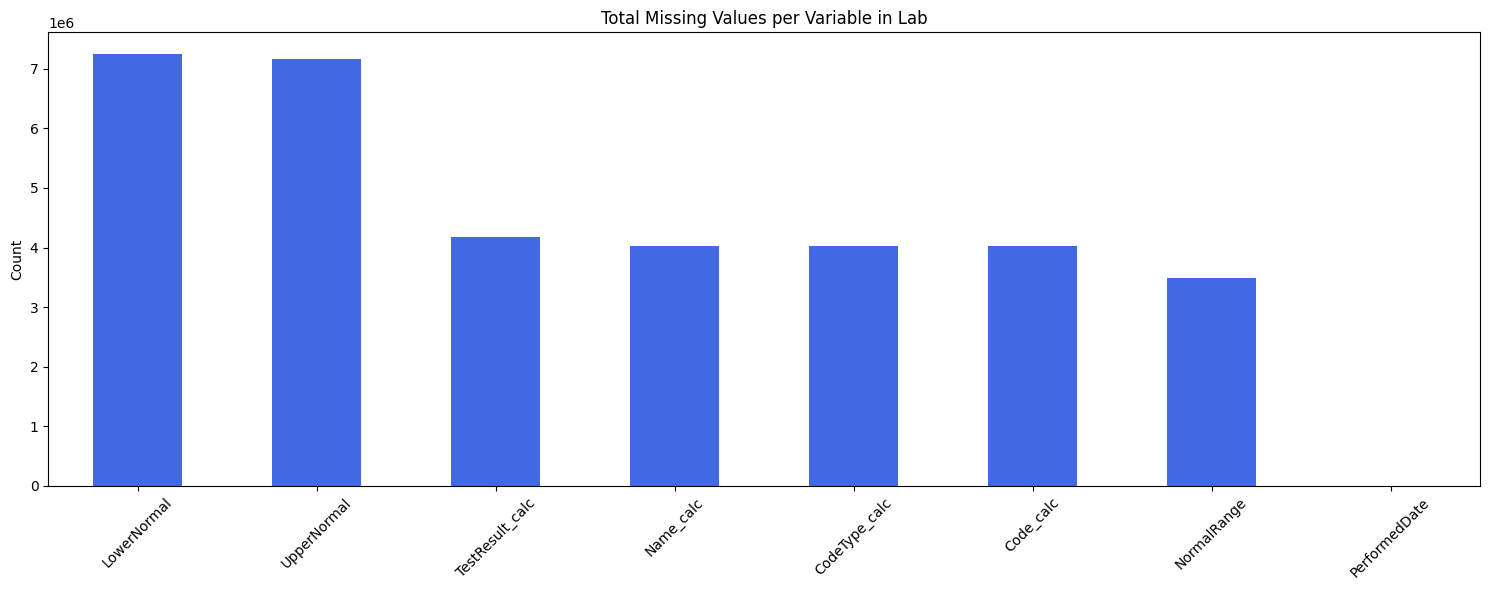

In [26]:
ax1 = lab_missing_counts[lab_missing_counts > 0].sort_values(ascending=False).plot(
    kind='bar', 
    color='royalblue',
    figsize=(15, 6)
)

ax1.tick_params(axis='x', rotation=45) 
ax1.set_title('Total Missing Values per Variable in Lab')
ax1.set_ylabel('Count')

plt.tight_layout() 
plt.show()

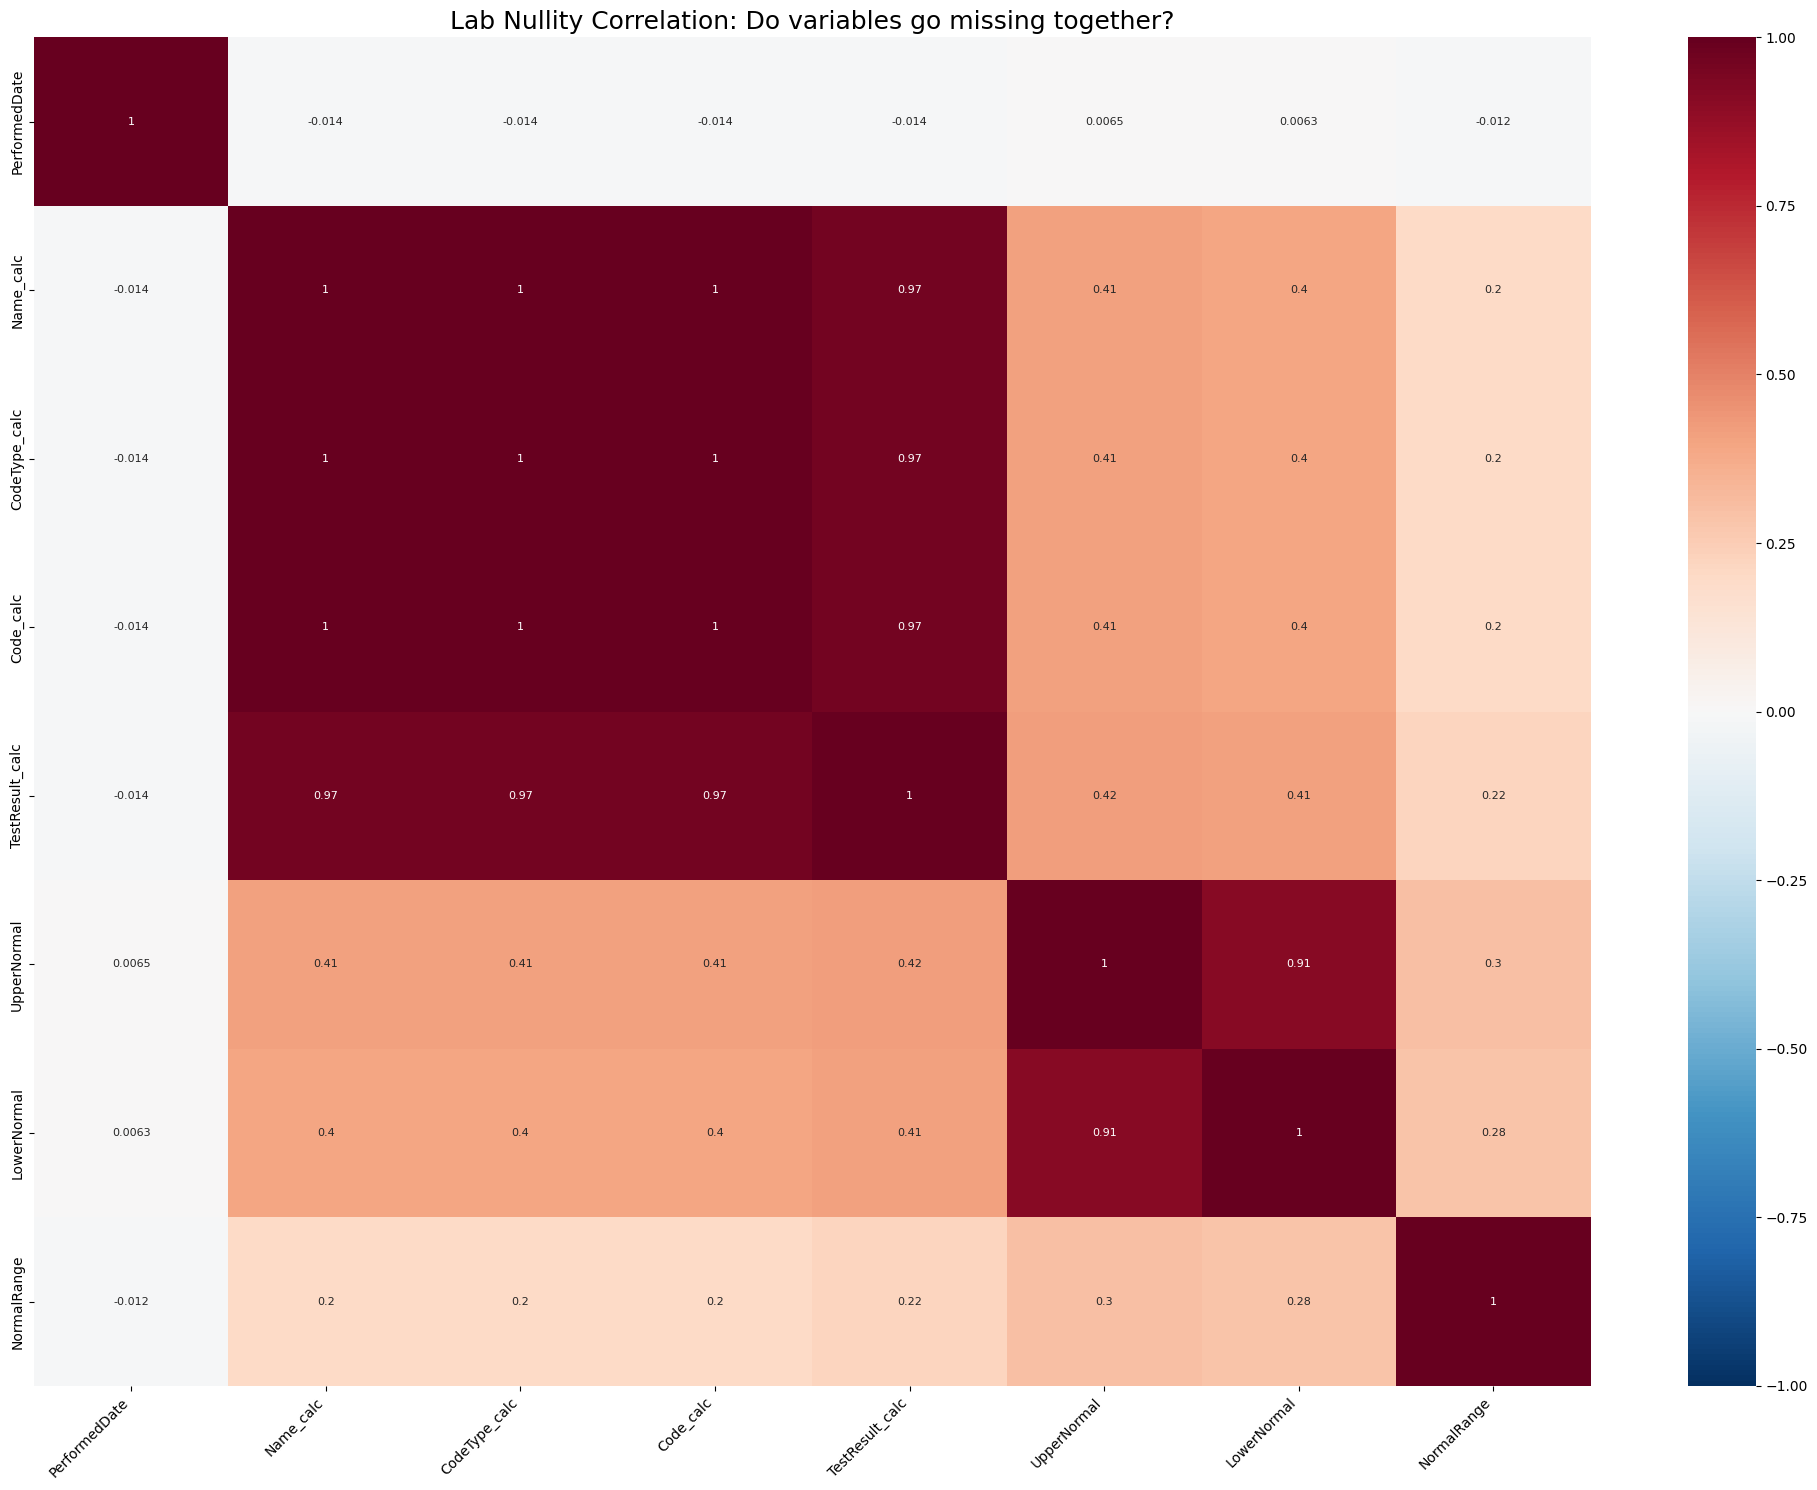

In [27]:
# Identify columns with missing values
lab_missing_cols = lab_clean.columns[lab_clean.isnull().any()].tolist()
 
# Create binary indicators (1 = Missing, 0 = Present)
lab_indicators = lab_clean[lab_missing_cols].isnull().astype(int)
 
# Calculate Nullity Correlation
lab_nullity_corr = lab_indicators.corr()
 
# Plot the results
plt.figure(figsize=(20, 15))

sns.heatmap(
    lab_nullity_corr, 
    annot=True, 
    cmap='RdBu_r', 
    center=0, 
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 8}
)

plt.title('Lab Nullity Correlation: Do variables go missing together?', fontsize=18)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Patient

In [28]:
# Detect Missingness in patient dataset
patient_missing_counts = patient_clean.isna().sum()

# To see the percentage of missing data per column instead of raw counts:
patient_missing_percentage = (patient_clean.isna().sum() / len(patient_clean)) * 100

# Combine into a summary table
patient_missing_summary = pd.concat([patient_missing_counts, patient_missing_percentage], axis=1)
patient_missing_summary.columns = ['Missing Count', 'Percentage']

patient_missing_summary.sort_values(by = 'Percentage', ascending=False)

,Missing Count,Percentage
BirthYear,141,0.040039
Sex,40,0.011358
Patient_ID,0,0.000000


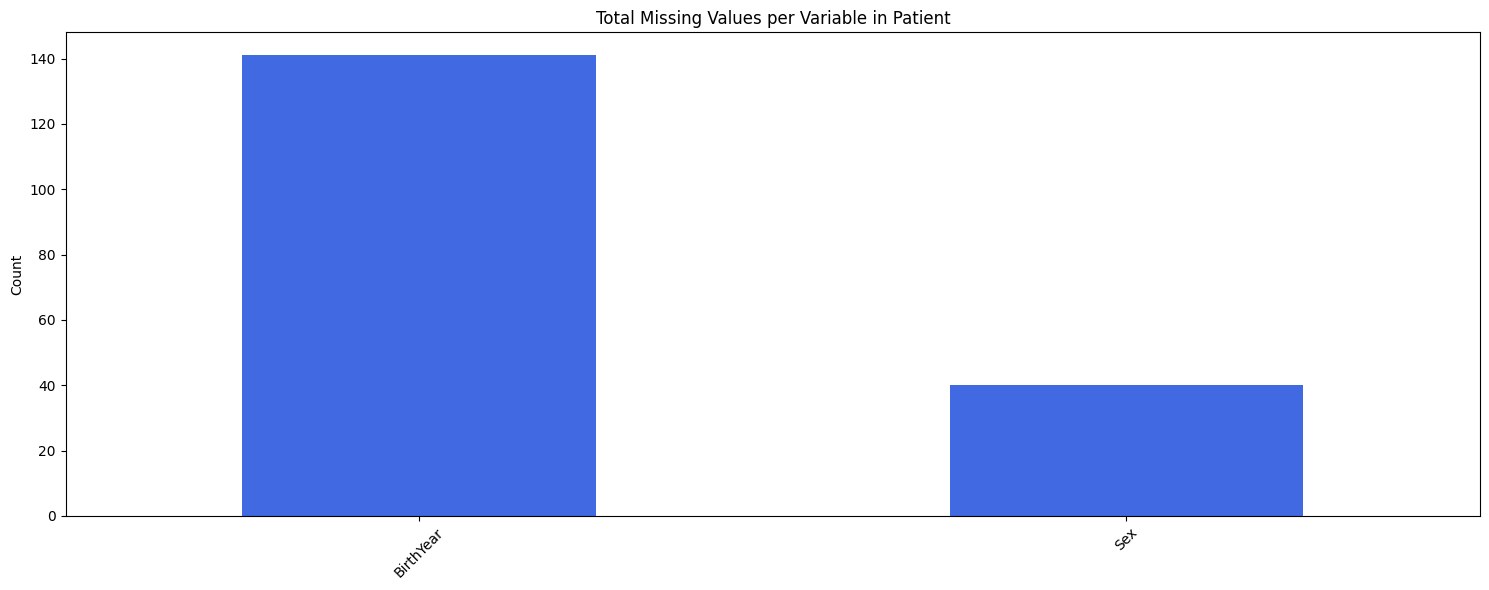

In [29]:
ax1 = patient_missing_counts[patient_missing_counts > 0].sort_values(ascending=False).plot(
    kind='bar', 
    color='royalblue',
    figsize=(15, 6)
)

ax1.tick_params(axis='x', rotation=45) 
ax1.set_title('Total Missing Values per Variable in Patient')
ax1.set_ylabel('Count')

plt.tight_layout() 
plt.show()

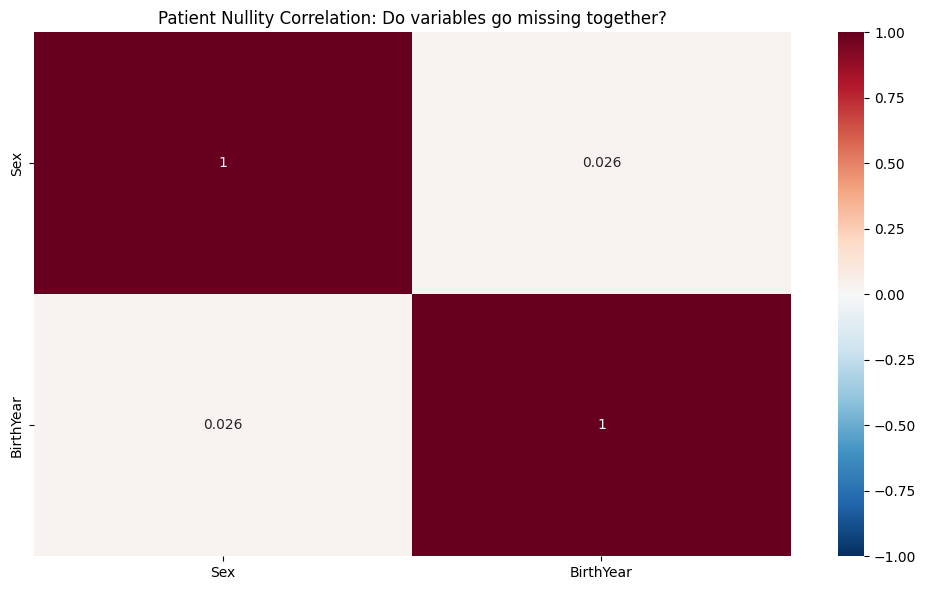

In [30]:
# Identify columns with missing values
patient_missing_cols = patient_clean.columns[patient_clean.isnull().any()].tolist()
 
# Create binary indicators (1 = Missing, 0 = Present)
patient_indicators = patient_clean[patient_missing_cols].isnull().astype(int)
 
# Calculate Nullity Correlation
patient_nullity_corr = patient_indicators.corr()
 
# Plot the results
plt.figure(figsize=(10, 6))
sns.heatmap(patient_nullity_corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Patient Nullity Correlation: Do variables go missing together?')
plt.tight_layout()

#### Family History

In [31]:
# Detect Missingness in family history dataset
family_missing_counts = family_clean.isna().sum()

# To see the percentage of missing data per column instead of raw counts:
family_missing_percentage = (family_clean.isna().sum() / len(family_clean)) * 100

# Combine into a summary table
family_missing_summary = pd.concat([family_missing_counts, family_missing_percentage], axis=1)
family_missing_summary.columns = ['Missing Count', 'Percentage']

family_missing_summary.sort_values(by = 'Percentage', ascending=False)

,Missing Count,Percentage
DiagnosisCode_orig,171255,52.661115
DiagnosisCodeType_orig,171126,52.621448
VitalStatus,165278,50.823181
Relationship_orig,27423,8.432605
DiagnosisText_orig,26843,8.254254
Patient_ID,0,0.000000
WasCauseOfDeath,0,0.000000
DateCreated,0,0.000000


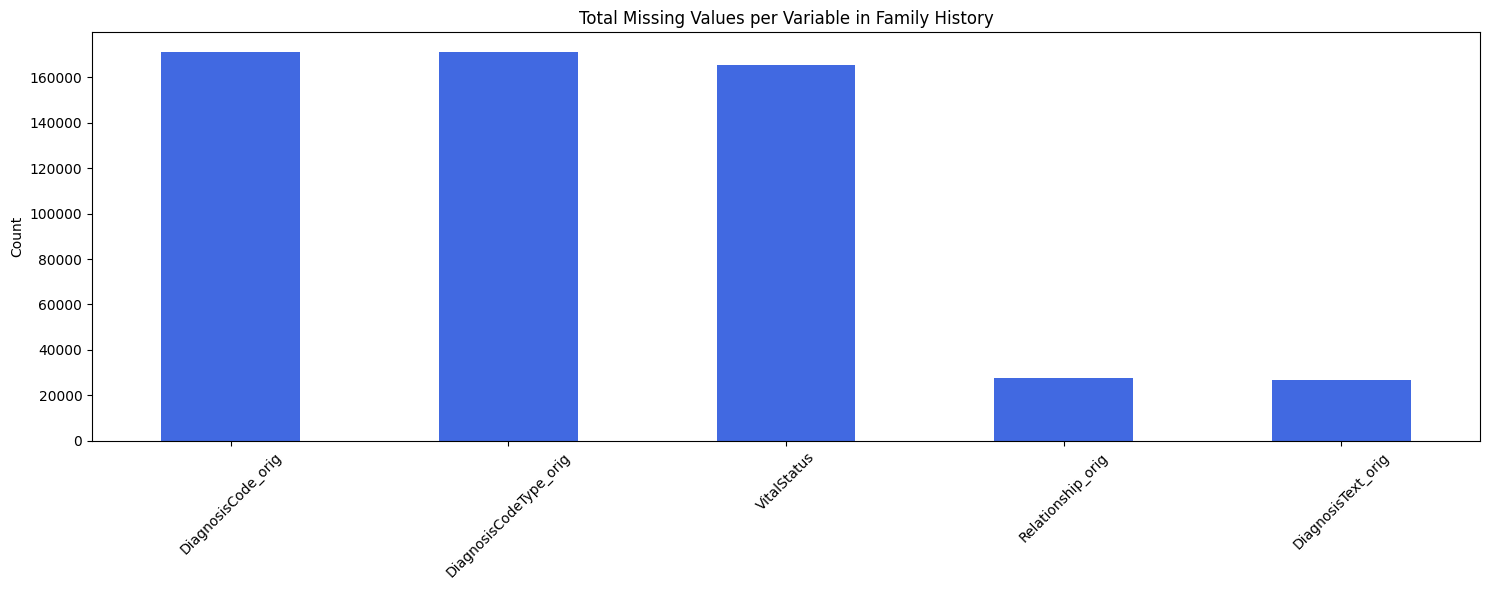

In [32]:
ax1 = family_missing_counts[family_missing_counts > 0].sort_values(ascending=False).plot(
    kind='bar', 
    color='royalblue',
    figsize=(15, 6)
)

ax1.tick_params(axis='x', rotation=45) 
ax1.set_title('Total Missing Values per Variable in Family History')
ax1.set_ylabel('Count')

plt.tight_layout() 
plt.show()

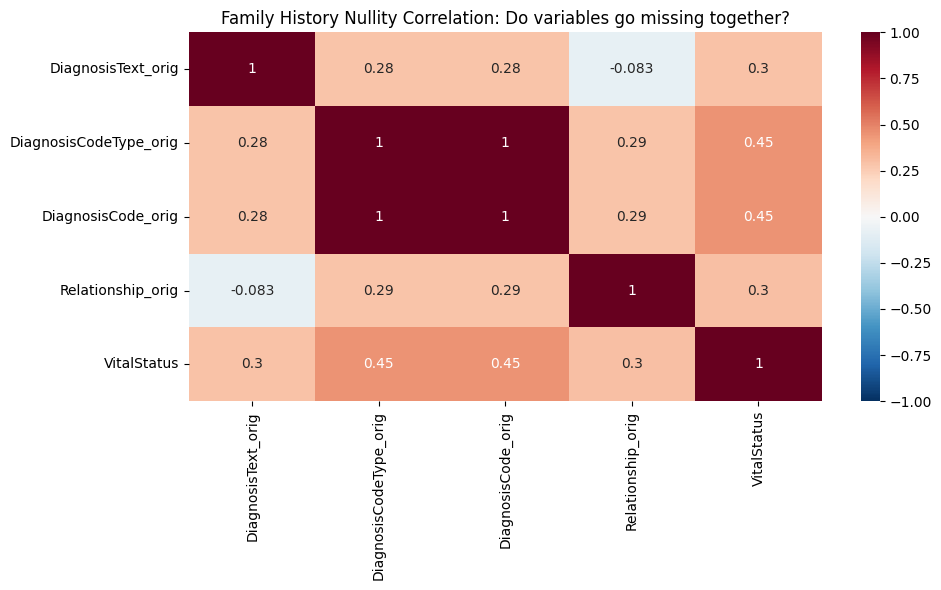

In [33]:
# Identify columns with missing values
family_missing_cols = family_clean.columns[family_clean.isnull().any()].tolist()
 
# Create binary indicators (1 = Missing, 0 = Present)
family_indicators = family_clean[family_missing_cols].isnull().astype(int)
 
# Calculate Nullity Correlation
family_nullity_corr = family_indicators.corr()
 
# Plot the results
plt.figure(figsize=(10, 6))
sns.heatmap(family_nullity_corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Family History Nullity Correlation: Do variables go missing together?')
plt.tight_layout()

In [34]:
# Creating a copy for complete data
# Imputation will be done using the copy, so we leave the original df unchanged
encounter_filled = encounter_clean.copy()
lab_filled = lab_clean.copy()
patient_filled = patient_clean.copy()
family_filled = family_clean.copy()

### Dealing with Missing Values

Only impute the necessary variables for our analysis:
- Encounter:
    EncounterDiagnosis_ID (no missing values),
    Patient_ID,
    DiagnosisCode_calc (remove patients with missing diagnosis codes, or use other columns to identify the possible code)
- Lab:
    Patient_ID,
    Name_calc (indicate which tests are used and drop missing values),
    TestResult_calc (drop missing values)
- Patient:
    Patient_ID,
    BirthYear (no missing values),
    Sex (no missing values)
- Family History:
    Patient_ID,
    DiagnosisText_orig,
    DiagnosisCode_orig (drop missing values),
    Relationship_orig (drop missing values)

Since our data are derived from clinical records, it is not appropriate to impute missing values, as each patient has unique characteristics and their conditions may differ substantially. Therefore, we decided to remove all rows containing missing values and retain only complete cases for the subsequent analysis (listwise deletion).

#### Encounter

In [35]:
# Drop all missing values
encounter_filled = encounter_filled.dropna()

In [36]:
# Detect Missingness in enounter dataset again
encounter_missing_counts = encounter_filled.isna().sum()
encounter_missing_counts

EncounterDiagnosis_ID     0
Patient_ID                0
Encounter_ID              0
DiagnosisText_calc        0
DiagnosisCodeType_calc    0
DiagnosisCode_calc        0
DateCreated               0
dtype: int64

In [37]:
# Count total number of patients after drop missing values
encounter_filled['Patient_ID'].nunique() 
# total number of patients (after drop NA): 298249
# 352,161 − 298,249 = 53,912 observations were dropped.

298249

#### Lab

In [38]:
# Drop all missing values
lab_filled = lab_filled.dropna()

In [39]:
# Detect Missingness in lab dataset again
lab_missing_counts = lab_filled.isna().sum()
lab_missing_counts

Patient_ID         0
PerformedDate      0
Name_calc          0
CodeType_calc      0
Code_calc          0
TestResult_calc    0
UpperNormal        0
LowerNormal        0
NormalRange        0
DateCreated        0
dtype: int64

In [40]:
# Count total number of patients after drop missing values
lab_filled['Patient_ID'].nunique() 
# total number of patients (after drop NA): 61439
# 207,836 − 61,439 = 145,924 observations were dropped.

61439

#### Patient

In [41]:
# Drop all missing values
patient_filled = patient_filled.dropna()

In [42]:
# Detect Missingness in patient dataset again
patient_missing_counts = patient_filled.isna().sum()
patient_missing_counts

Patient_ID    0
Sex           0
BirthYear     0
dtype: int64

In [43]:
# Count total number of patients after drop missing values
patient_filled['Patient_ID'].nunique() 
# total number of patients (after drop NA): 351,982
# 352,161 − 351,982 = 179 observations were dropped.

351982

#### Family History

In [44]:
# Drop all missing values
family_filled = family_filled.dropna()

In [45]:
# Detect Missingness in family dataset again
family_missing_counts = family_filled.isna().sum()
family_missing_counts

Patient_ID                0
DiagnosisText_orig        0
DiagnosisCodeType_orig    0
DiagnosisCode_orig        0
Relationship_orig         0
VitalStatus               0
WasCauseOfDeath           0
DateCreated               0
dtype: int64

In [46]:
# Count total number of patients after drop missing values
family_filled['Patient_ID'].nunique() 
# total number of patients (after drop NA): 32565
# 92,902 − 32,565 = 60,337 observations were dropped.

32565

### Combined four dataset by patient id

In [ ]:
df_combined = (encounter_filled.merge(patient_filled, on='Patient_ID', how='outer')
                               .merge(lab_filled, on='Patient_ID', how='outer')
                               .merge(family_filled, on='Patient_ID', how='outer'))

df_combined.head(10)

In [ ]:
df_combined['Patient_ID'].nunique() 

In [ ]:
OUTPUT_PATH = 'cleaned data/combined_df.csv'
df_combined.to_csv(OUTPUT_PATH, index=False)